In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
data = pd.read_csv("Datasets/train.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [35]:
data.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [36]:
data.shape

(891, 12)

In [37]:
cols = [var for var in data.columns if data[var].isnull().mean() < 1.00 and data[var].isnull().mean() > 0]
cols

['Age', 'Cabin', 'Embarked']

In [38]:
data[cols].sample(5)

,Age,Cabin,Embarked
154,NaN,NaN,S
739,NaN,NaN,S
132,47.0,NaN,S
515,47.0,D46,S
199,24.0,NaN,S


In [39]:
data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [40]:
len(data[cols].dropna()) / len(data)

0.2053872053872054

In [41]:
new_df = data[cols].dropna()
data.shape, new_df.shape

((891, 12), (183, 3))

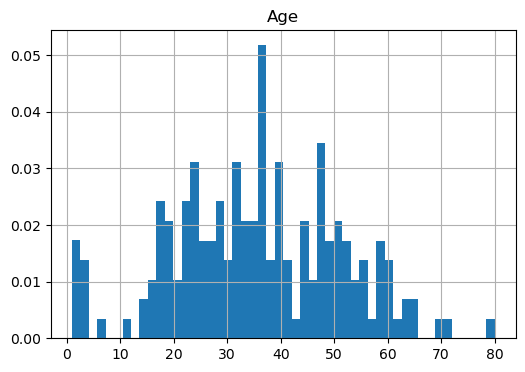

In [42]:
new_df.hist(bins=50, density=True, figsize=(6, 4))
plt.show()

<Axes: >

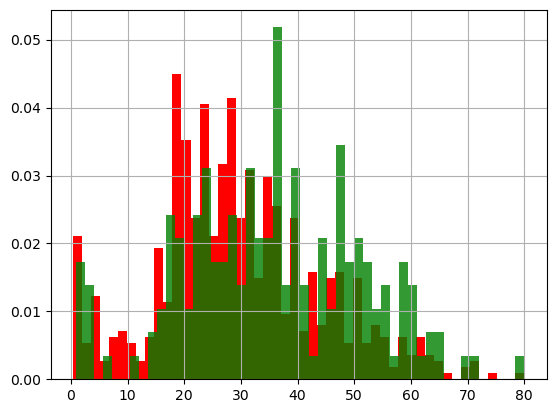

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
data['Age'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['Age'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

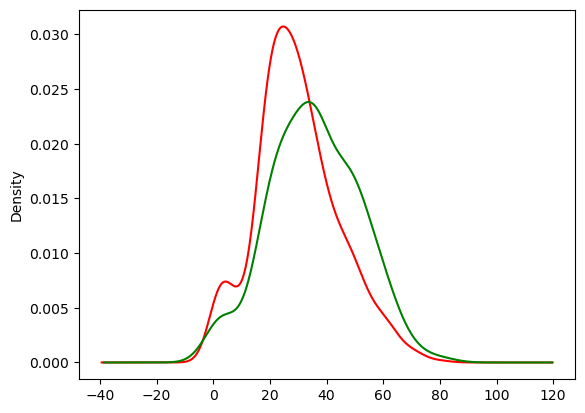

In [45]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
data['Age'].plot.density(color='red')

# data after cca
new_df['Age'].plot.density(color='green')

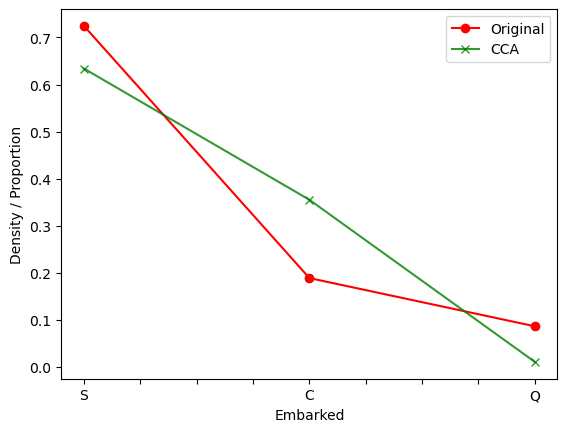

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111)

# 1. ADDED .value_counts(normalize=True) to calculate proportions for original data
data["Embarked"].value_counts(normalize=True).plot(
    kind="line", ax=ax, color="red", marker="o", label="Original"
)

# 2. ADDED .value_counts(normalize=True) to calculate proportions for CCA data
new_df["Embarked"].value_counts(normalize=True).plot(
    kind="line", ax=ax, color="green", marker="x", alpha=0.8, label="CCA"
)

plt.ylabel("Density / Proportion")
plt.legend()
plt.show()
